In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)
print(torch.cuda.get_arch_list())


True
NVIDIA GeForce RTX 5080
12.8
['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
window_size = 30
pad_value = 0

In [5]:
exclude_rgb_vis=False
exclude_weather_features=True
exclude_canopy_temp=True
dataset_name = "stratified_train_test_datasets_v5_all_interpolated.xlsx"

In [6]:
import numpy as np
import random

seed = 42
random.seed(seed)

torch.manual_seed(seed)
np.random.seed(seed)

torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

g = torch.Generator()
g.manual_seed(seed)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [7]:
from features import *

vi_features = get_vi_features(exclude_rgb_vis=exclude_rgb_vis)
weather_features = get_weather_features(exclude=exclude_weather_features)
canopy_temp_features = get_canopy_temp_features(exclude=exclude_canopy_temp)
features = vi_features + weather_features + canopy_temp_features

output_variable = get_output_variable()


Text(0.5, 1.0, 'Train vs Test Yield Distribution')

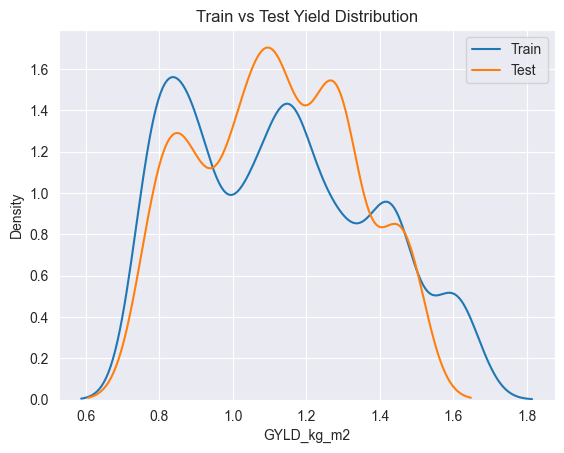

In [8]:
# Loading saved training test
train_df = pd.read_excel(f"data/{dataset_name}", sheet_name='Train')
test_df = pd.read_excel(f"data/{dataset_name}", sheet_name='Test')

sns.kdeplot(train_df[output_variable], label='Train')
sns.kdeplot(test_df[output_variable], label='Test')
plt.legend()
plt.title("Train vs Test Yield Distribution")

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

scaler_X = StandardScaler()
scaler_y = RobustScaler()

# Fit on training features and yield only
scaler_X.fit(train_df[features])
scaler_y.fit(train_df[[output_variable]])

train_df_scaled = train_df.copy()
test_df_scaled  = test_df.copy()

# --- Scaled features and target variable---
train_df_scaled[features] = scaler_X.transform(train_df[features])
train_df_scaled[output_variable] = scaler_y.transform(train_df[[output_variable]])

test_df_scaled[features] = scaler_X.transform(test_df[features])
test_df_scaled[output_variable] = scaler_y.transform(test_df[[output_variable]])

In [10]:

num_na_rows = train_df_scaled.isna().any(axis=1).sum()
print(f"train_df_scaled Rows with at least one NaN: {num_na_rows}")

num_na_rows = test_df_scaled.isna().any(axis=1).sum()
print(f"test_df_scaled Rows with at least one NaN: {num_na_rows}")


train_df_scaled Rows with at least one NaN: 0
test_df_scaled Rows with at least one NaN: 0


In [11]:
from train_eval_functions import train_data, evaluate_model
import optuna
from torch.utils.data import DataLoader
from helper import make_progressive_windows
from model_definitions import GRUModel
from vi_dataset import VIDataset


C:\Users\lochana.marasingha\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


K-fold cross validation

In [ ]:
# from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# kf = KFold(n_splits=5, shuffle=True, random_state=42)
plot_ids = train_df['plot_id'].unique()
yield_per_plot = train_df.groupby('plot_id')[output_variable].first().values

y_bins = pd.qcut(yield_per_plot, q=5, labels=False)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)


In [ ]:
def k_fold_cross_validation(trial_id, batch_size, k_fold_epochs, hidden_size, num_layers, dropout, bidirectional, learning_rate, weight_decay, hyper_param_criterion_method):

    r2_scores = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(plot_ids, y_bins)):
        print(f"Fold {fold+1}")

        train_plots = plot_ids[train_idx]
        val_plots   = plot_ids[val_idx]

        train_df_fold = train_df[train_df['plot_id'].isin(train_plots)]
        val_df_fold   = train_df[train_df['plot_id'].isin(val_plots)]

        # Scaling
        scaler_X_fold = StandardScaler()
        scaler_y_fold = RobustScaler()

        scaler_X_fold.fit(train_df_fold[features])
        scaler_y_fold.fit(train_df_fold[[output_variable]])

        train_df_fold_scaled = train_df_fold.copy()
        val_df_fold_scaled  = val_df_fold.copy()

        train_df_fold_scaled[features] = scaler_X_fold.transform(train_df_fold[features])
        train_df_fold_scaled[output_variable] = scaler_y_fold.transform(train_df_fold[[output_variable]])

        val_df_fold_scaled[features] = scaler_X_fold.transform(val_df_fold[features])
        val_df_fold_scaled[output_variable] = scaler_y_fold.transform(val_df_fold[[output_variable]])

        X_train_fold, y_train_fold, valid_length_train_fold, no_days_train_fold  = make_progressive_windows(
            dataframe=train_df_fold_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

        X_val_fold, y_val_fold, valid_length_test_fold, no_days_test_fold= make_progressive_windows(
            dataframe=val_df_fold_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

        train_dataset_fold = VIDataset(X_train_fold, y_train_fold, valid_length_train_fold)
        val_dataset_fold = VIDataset(X_val_fold, y_val_fold, valid_length_test_fold)

        train_loader_fold  = DataLoader(train_dataset_fold, batch_size=batch_size, shuffle=True, worker_init_fn=seed_worker, generator=g)
        val_loader_fold    = DataLoader(val_dataset_fold, batch_size=batch_size, shuffle=False,
                                        worker_init_fn=seed_worker, generator=g)

        model = GRUModel(input_size = len(features), hidden_size = hidden_size, num_layers = num_layers,
                         output_size= 1, dropout=dropout, bidirectional = bidirectional).to(device)

        train_data(
            model = model,
            model_train_loader= train_loader_fold,
            num_epochs = k_fold_epochs,
            learning_rate = learning_rate,
            weight_decay = weight_decay,
            hyper_param_criterion_method = hyper_param_criterion_method,
            file_save_name="",
            early_stopping=True
        )

        r2, mse, mae = evaluate_model(
            model = model,
            val_loader = val_loader_fold,
            output_variable_scaler=scaler_y_fold)

        r2_scores.append(r2)
        print(f" Trial: {trial_id}, Fold {fold+1} R²: {r2:.4f}")

    mean_r2 = np.mean(r2_scores)
    print(f"\n Trial: {trial_id}, Mean R² across folds: {mean_r2:.4f}")
    return mean_r2

In [ ]:

# search_space = {
#     "hidden_size": [8, 16, 32 , 64],
#     "num_layers": [1, 2, 3],
#     "dropout": [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
#     "lr":  [0.00001, 0.0001, 0.001, 0.01],
#     "batch_size": [8, 16, 32, 64],
# }

tuning_epochs = 500

def objective(trial):
    hidden_size = trial.suggest_categorical('hidden_size', [8, 16, 32 , 64])
    num_layers = trial.suggest_categorical('num_layers', [1, 2, 3])
    dropout = trial.suggest_float('dropout', 0.0,  0.5)
    lr = trial.suggest_float('lr', 1e-4,  1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-10, 1e-3, log=True)
    # bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])

    mean_r2 = k_fold_cross_validation(
        trial_id=trial.number,
        batch_size= batch_size,
        k_fold_epochs=tuning_epochs,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=False,
        learning_rate=lr,
        weight_decay=weight_decay,
        hyper_param_criterion_method="L1Loss")
    return mean_r2


In [ ]:
sampler = optuna.samplers.TPESampler(seed=seed)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=100)

print(f"Best R²: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)


In [ ]:

# cols_to_pad = canopy_temp_features + weather_features
# train_df_scaled[cols_to_pad] = train_df_scaled[cols_to_pad].fillna(pad_value)
# test_df_scaled[cols_to_pad] = test_df_scaled[cols_to_pad].fillna(pad_value)


In [ ]:
X_train_scaled, y_train_scaled, valid_length_train, no_days_train = make_progressive_windows(
        dataframe=train_df_scaled,
        features=features,
        output_variable=output_variable,
        window_size=window_size,
        pad_value=pad_value)

X_test_scaled, y_test_scaled, valid_length_test, no_days_test  = make_progressive_windows(
    dataframe=test_df_scaled,
    features=features,
    output_variable=output_variable,
    window_size=window_size,
    pad_value=pad_value)

train_dataset = VIDataset(X_train_scaled, y_train_scaled, valid_length_train)
test_dataset = VIDataset(X_test_scaled, y_test_scaled, valid_length_test)


In [ ]:
from train_eval_functions import validation_with_test

epochs = 1000

def hyper_param_objective(trial):
    hidden_size = trial.suggest_categorical('hidden_size', [8, 16, 32 , 64])
    num_layers = trial.suggest_categorical('num_layers', [1, 2, 3])
    dropout = trial.suggest_float('dropout', 0.0,  0.5)
    lr = trial.suggest_float('lr', 1e-4,  1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-10, 1e-3, log=True)
    # bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])

    mean_r2 = validation_with_test(
        trial_id = trial.number,
        train_dataset = train_dataset,
        test_dataset = test_dataset,
        features = features,
        scaler_y=scaler_y,
        batch_size= batch_size,
        num_epochs=epochs,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=False,
        learning_rate=lr,
        weight_decay=weight_decay,
        hyper_param_criterion_method="L1Loss")
    return mean_r2

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(hyper_param_objective, n_trials=50)

print(f"Best R²: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)

In [ ]:
# =============================================
#  Train the best model with best hyper params
# =============================================

best_gru_params = {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.35608325226573156, 'lr': 0.003252544155042998, 'weight_decay': 2.387419376263318e-08, 'batch_size': 16}

best_model = GRUModel(
    input_size=len(features),
    hidden_size=best_gru_params['hidden_size'],
    num_layers=best_gru_params['num_layers'],
    output_size=1,
    dropout=best_gru_params['dropout'],
    bidirectional=False).to(device)

In [ ]:
train_loader  = DataLoader(train_dataset, batch_size=best_gru_params['batch_size'], shuffle=True)
test_loader    = DataLoader(test_dataset, batch_size=best_gru_params['batch_size'], shuffle=False)

In [ ]:
# Optional: Train again with best hyper parameters

epochs = 1000
criterion_method="L1Loss"

train_losses = train_data(
            model = best_model,
            model_train_loader= train_loader,
            num_epochs = epochs,
            learning_rate = best_gru_params['lr'],
            weight_decay = best_gru_params['weight_decay'],
            hyper_param_criterion_method = criterion_method,
            file_save_name ="best_model_gru_kfold_1.pth",
            early_stopping = True,
        )


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, 200+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

In [ ]:
from train_eval_functions import evaluate_model

state_dict = torch.load("best_model_gru_kfold_1.pth", map_location=device)
best_model.load_state_dict(state_dict)

# Training metrics
r2_train, mse_train, mae_train = evaluate_model(best_model, train_loader, output_variable_scaler=scaler_y, do_inverse_transform= True, plot_pred_vs_true=True)
# Test metrics
r2_test, mse_test, mae_test = evaluate_model(best_model, test_loader, output_variable_scaler=scaler_y, do_inverse_transform= True, plot_pred_vs_true=True)

print(f'Train R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}')
print(f'Test R²: {r2_test:.4f}, Test MSE: {mse_test:.4f}')


In [ ]:
# save model
torch.save(best_model, "best_gru_models/best_model_full_1.pth")

# save Scalers for future predictions
import joblib

joblib.dump(scaler_X, "best_gru_models/scalers/scaler_X_1.save")
joblib.dump(scaler_y, "best_gru_models/scalers/scaler_y_1.save")